In [1]:
# This notebook contains the core simulation structure for a 2D low Earth orbit communications network,
# but leaves key functions for you to implement. The goal is to guide you through the mathematics and
# algorithms while you learn by doing.
#
# How to use
# ----------
# - Open this file as a Jupyter Notebook.
# - Work cell by cell. Read the instructions in each markdown cell first.
# - Implement the functions marked with `NASIA TODO` and run the tests.
# - If a test fails, read the hint and try again. Ask/email me if you get stuck.
#
# After completing the scaffold, you will have (i) built a visibility-based connectivity graph,
# (ii) implemented Dijkstra for shortest path distance, (iii) animated the signal transmission.

In [2]:
import math
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [3]:
# First, we define some constants, and the `Node` data structure.
# Each node will represent 1 satellite in orbit or 1 ground station.

In [4]:
R_EARTH_KM = 6371.0  # Earth radius in kilometres
C_KM_S = 299792.458  # Speed of light in km/s

@dataclass
class Node:
    id: str
    pos: Tuple[float, float]
    type: str  # 'sat' or 'ground'

In [5]:
# Nasia to-do list:
# -----------------
# Implement the following small geometry functions. They are used by the rest of the simulation.
# Each function has a short test below it to help you verify correctness.

# NASIA TODO: implement these functions

In [6]:
def polar_to_cartesian(radius_km: float, angle_rad: float) -> Tuple[float, float]:
    """Convert polar coordinates (radius, angle) to Cartesian (x, y)."""
    x = radius_km * math.cos(angle_rad)
    y = radius_km * math.sin(angle_rad)
    return (x, y)


# Quick test for polar_to_cartesian

try:
    # angle 0 -> point on +x axis
    assert polar_to_cartesian(1.0, 0.0) == (1.0, 0.0)
    # angle pi/2 -> point on +y axis (allow float tolerance)
    x, y = polar_to_cartesian(2.0, math.pi/2)
    assert abs(x) < 1e-9 and abs(y - 2.0) < 1e-9
    print('polar_to_cartesian: quick tests passed')
except NotImplementedError:
    print('polar_to_cartesian: not implemented yet')
except AssertionError:
    print('polar_to_cartesian: tests failed — check your math')


polar_to_cartesian: quick tests passed


In [7]:
def euclidean_distance(p1: Tuple[float, float], p2: Tuple[float, float]) -> float:
    """Return Euclidean distance between two 2D points (in km)."""
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    return math.sqrt(dx*dx + dy*dy)



# Quick test for euclidean_distance
try:
    assert abs(euclidean_distance((0,0), (3,4)) - 5.0) < 1e-9
    print('euclidean_distance: quick tests passed')
except NotImplementedError:
    print('euclidean_distance: not implemented yet')
except AssertionError:
    print('euclidean_distance: tests failed — check your formula')

euclidean_distance: quick tests passed


In [8]:
# Visibility test (Nasia TODO)
# ----------------------------
# Implement a function that checks whether the straight segment between two points intersects the Earth's disc.
# The helper function `segment_min_dist_to_origin` is provided and may be useful.

def segment_min_dist_to_origin(p1: Tuple[float, float], p2: Tuple[float, float]) -> float:
    """Compute minimum distance from origin to the segment p1-p2."""
    x1, y1 = p1
    x2, y2 = p2
    dx = x2 - x1
    dy = y2 - y1
    if dx == 0 and dy == 0:
        return math.hypot(x1, y1)
    t = -(x1 * dx + y1 * dy) / (dx * dx + dy * dy)
    t_clamped = max(0.0, min(1.0, t))
    proj_x = x1 + t_clamped * dx
    proj_y = y1 + t_clamped * dy
    return math.hypot(proj_x, proj_y)

# NASIA TODO: implement line_of_sight

R_EARTH_KM = 6371.0  # Earth radius in kilometres

def line_of_sight(p1: Tuple[float, float], p2: Tuple[float, float], earth_radius_km: float = R_EARTH_KM) -> bool:
    """Return True if the straight line between p1 and p2 is not blocked by Earth."""
    min_dist = segment_min_dist_to_origin(p1, p2)
    return min_dist >= earth_radius_km


# Quick tests for visibility
try:
    p_above = (R_EARTH_KM + 500.0, 0.0)
    p_opposite = (-(R_EARTH_KM + 500.0), 0.0)
    # A link that passes through Earth should be blocked
    assert not line_of_sight(p_above, p_opposite)
    # Two close points above same side should have line of sight
    p1 = (R_EARTH_KM + 500.0, 0.0)
    p2 = (R_EARTH_KM + 500.0, 100.0)
    assert line_of_sight(p1, p2)
    print('line_of_sight: quick tests passed')
except NotImplementedError:
    print('line_of_sight: not implemented yet')
except AssertionError:
    print('line_of_sight: tests failed — check your logic')

line_of_sight: quick tests passed


In [9]:
# Build nodes and visibility graph
# -----------------------------------
# The `Simulation` class below is mostly complete. It uses the functions implemented above.
# Read the code and run the next cell. If your implementations are correct, the simulation 
# should build a graph and find a shortest path between the two ground stations.

class Simulation:
    def __init__(self, num_sats=24, altitude_km=550.0, 
                 ground_angles_deg=None, max_isl_km=None, processing_delay_s=0.005):
        self.num_sats = num_sats
        self.altitude_km = altitude_km
        self.ground_angles_deg = ground_angles_deg or [0.0, 60.0]
        self.max_isl_km = max_isl_km
        self.processing_delay_s = processing_delay_s

        self.nodes = []
        self.graph = {}

        self.build_nodes_ring()
        self.build_visibility_graph()

    def build_nodes_ring(self):
        sat_radius = R_EARTH_KM + self.altitude_km
        nodes = []
        for i in range(self.num_sats):
            ang = 2 * math.pi * i / self.num_sats
            pos = polar_to_cartesian(sat_radius, ang)
            nodes.append(Node(id=f"S{i}", pos=pos, type="sat"))
        for idx, adeg in enumerate(self.ground_angles_deg):
            ang = math.radians(adeg)
            pos = polar_to_cartesian(R_EARTH_KM, ang)
            nodes.append(Node(id=f"G{idx}", pos=pos, type="ground"))
        self.nodes = nodes

    def build_visibility_graph(self):
        graph = {n.id: [] for n in self.nodes}
        for i, a in enumerate(self.nodes):
            for j, b in enumerate(self.nodes):
                if i == j:
                    continue
                if a.type == "ground" and b.type == "ground":
                    continue
                if line_of_sight(a.pos, b.pos):
                    d = euclidean_distance(a.pos, b.pos)
                    if a.type == "sat" and b.type == "sat" and (self.max_isl_km is not None) and (d > self.max_isl_km):
                        continue
                    delay = d / C_KM_S + self.processing_delay_s
                    graph[a.id].append((b.id, delay))
        self.graph = graph

    #NASIA TODO: implement shortest_path using Dijkstra
    def shortest_path(self, source: str, target: str) -> Tuple[Optional[float], List[str]]:
        pq = [(0.0, source)]

        dist = {node.id: math.inf for node in self.nodes}
        dist[source] = 0.0

        prev = {node.id: None for node in self.nodes}

        while pq:
            current_dist, u = heapq.heappop(pq)

            if u == target:
                break

            if current_dist > dist[u]:
                continue

            for v, weight in self.graph[u]:
                new_dist = current_dist + weight
                if new_dist < dist[v]:
                    dist[v] = new_dist
                    prev[v] = u
                    heapq.heappush(pq, (new_dist, v))

        if dist[target] == math.inf:
            return None, []

        path = []
        node = target
        while node is not None:
            path.append(node)
            node = prev[node]
        path.reverse()

        return dist[target], path

def plot_shortest_path(sim: Simulation, path: List[str]):
    plt.figure(figsize=(8, 8))

    earth = plt.Circle((0, 0), R_EARTH_KM, color='lightblue', alpha=0.5)
    plt.gca().add_patch(earth)

    for node in sim.nodes:
        x, y = node.pos
        if node.type == "sat":
            plt.plot(x, y, 'ro', markersize=5)
        else:
            plt.plot(x, y, 'bo', markersize=8)
        plt.text(x, y, node.id, fontsize=8)

    for a in sim.nodes:
        for b_id, _ in sim.graph[a.id]:
            b = next(n for n in sim.nodes if n.id == b_id)
            x1, y1 = a.pos
            x2, y2 = b.pos
            plt.plot([x1, x2], [y1, y2], 'gray', linewidth=0.5, alpha=0.4)

    for i in range(len(path) - 1):
        a = next(n for n in sim.nodes if n.id == path[i])
        b = next(n for n in sim.nodes if n.id == path[i+1])
        x1, y1 = a.pos
        x2, y2 = b.pos
        plt.plot([x1, x2], [y1, y2], 'yellow', linewidth=3)

    plt.gca().set_aspect('equal', adjustable='box')
    plt.title("Shortest Path Through Satellite Network")
    plt.xlabel("x (km)")
    plt.ylabel("y (km)")
    plt.grid(True)
    plt.show()



Path: ['G0', 'S1', 'S2', 'S3', 'G1']
Total delay: 0.044185883651807104


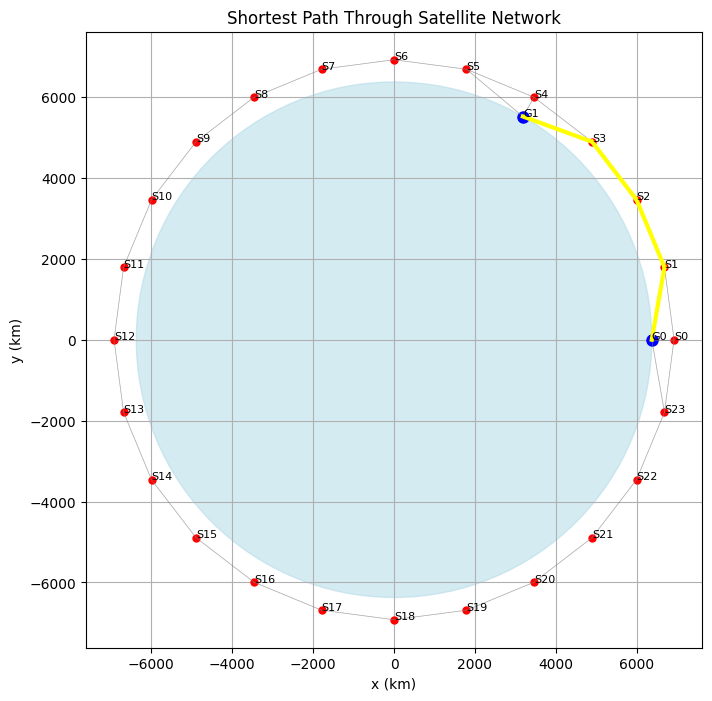

Path found: ['G0', 'S1', 'S2', 'S3', 'G1']
Total delay: 0.0441859 s


In [10]:
# Quick integration test
# ----------------------
# Run the simulation now. If your functions are implemented correctly, the
# simulation will find a path between G0 and G1 and print summary metrics.


try:
    # Example run: adjust parameters if needed
    sim = Simulation(num_sats=24, altitude_km=550.0, ground_angles_deg=[0.0, 60.0], max_isl_km=2500.0)
    total_delay, path = sim.shortest_path('G0', 'G1')

    print("Path:", path)
    print("Total delay:", total_delay)

    plot_shortest_path(sim, path)

    if total_delay is None:
        print('No path found: try changing parameters or check your implementations')
    else:
        print('Path found:', path)
        print(f'Total delay: {total_delay:.6g} s')
except NotImplementedError:
    print('shortest_path not implemented yet')

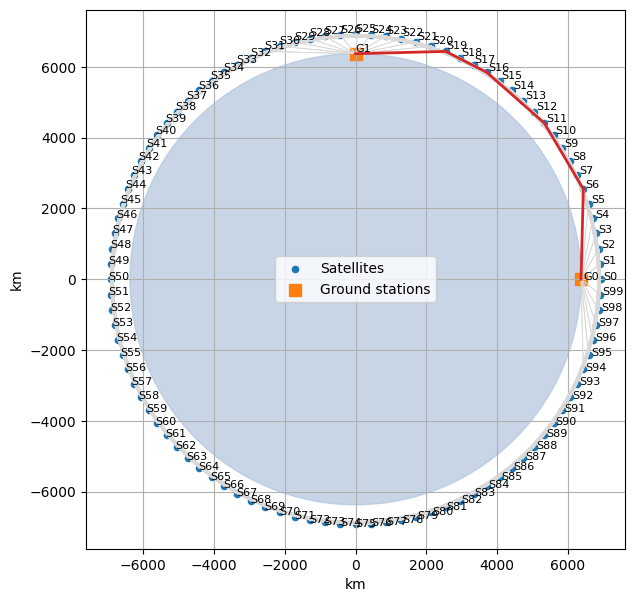

In [11]:
# Visualisations/animations
# -------------------------
# The plotting helpers below are given to you. Once you implemented the
# functions above and `shortest_path`, the animation will show a signal
# travelling along the computed route. You will not need to modify these cells
# unless you want to make the plot prettier.

def plot_topology(nodes, graph, altitude_km, highlight_path=None):
    fig, ax = plt.subplots(figsize=(7, 7))
    earth = plt.Circle((0, 0), R_EARTH_KM, color='lightsteelblue', alpha=0.7)
    ax.add_patch(earth)

    sats = [n for n in nodes if n.type == 'sat']
    gs = [n for n in nodes if n.type == 'ground']

    ax.scatter([s.pos[0] for s in sats], [s.pos[1] for s in sats], s=20, label='Satellites')
    ax.scatter([g.pos[0] for g in gs], [g.pos[1] for g in gs], s=80, marker='s', color='tab:orange', label='Ground stations')

    for n in nodes:
        ax.text(n.pos[0] * 1.01, n.pos[1] * 1.01, n.id, fontsize=8)

    for a in nodes:
        for b_id, _ in graph[a.id]:
            b = next(n for n in nodes if n.id == b_id)
            ax.plot([a.pos[0], b.pos[0]], [a.pos[1], b.pos[1]], color='0.85', linewidth=0.6)

    if highlight_path is not None and len(highlight_path) > 1:
        for i in range(len(highlight_path) - 1):
            a = next(n for n in nodes if n.id == highlight_path[i])
            b = next(n for n in nodes if n.id == highlight_path[i+1])
            ax.plot([a.pos[0], b.pos[0]], [a.pos[1], b.pos[1]], color='tab:red', linewidth=2.0)

    limit = 1.1 * (R_EARTH_KM + altitude_km)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_xlabel('km')
    ax.set_ylabel('km')
    ax.grid(True)
    ax.legend()
    plt.show()

sim = Simulation(num_sats=100, altitude_km=550.0, ground_angles_deg=[0.0, 90.0], max_isl_km=2500.0)
total_delay, path = sim.shortest_path("G0", "G1")

plot_topology(sim.nodes, sim.graph, sim.altitude_km, highlight_path=path)
#for redunduncy of 5 minimum number satellites is 94 and maximum number of satellites is 109.


In [12]:
def animate_path_slider(sim, path, processing_delay_s=None):
    if processing_delay_s is None:
        processing_delay_s = sim.processing_delay_s
    hops = []
    for i in range(len(path)-1):
        a = next(n for n in sim.nodes if n.id == path[i])
        b = next(n for n in sim.nodes if n.id == path[i+1])
        prop_delay = euclidean_distance(a.pos, b.pos) / C_KM_S
        proc_delay = processing_delay_s if (i < len(path)-1) else 0.0
        hops.append({'from': path[i], 'to': path[i+1], 'prop': prop_delay, 'proc': proc_delay, 'a_pos': a.pos, 'b_pos': b.pos})
    # build time segments
    time_segments = []
    t_cursor = 0.0
    for h in hops:
        time_segments.append(('prop', h['a_pos'], h['b_pos'], t_cursor, t_cursor + h['prop']))
        t_cursor += h['prop']
        if h['proc'] > 0:
            time_segments.append(('proc', h['b_pos'], h['b_pos'], t_cursor, t_cursor + h['proc']))
            t_cursor += h['proc']
    total_time = t_cursor

    fig, ax = plt.subplots(figsize=(7, 7))
    plt.subplots_adjust(bottom=0.15)
    earth = plt.Circle((0, 0), R_EARTH_KM, color='lightsteelblue', alpha=0.7)
    ax.add_patch(earth)
    ax.scatter([n.pos[0] for n in sim.nodes if n.type == 'sat'], [n.pos[1] for n in sim.nodes if n.type == 'sat'], s=20)
    ax.scatter([n.pos[0] for n in sim.nodes if n.type == 'ground'], [n.pos[1] for n in sim.nodes if n.type == 'ground'], s=80, marker='s', color='tab:orange')
    for n in sim.nodes:
        ax.text(n.pos[0] * 1.01, n.pos[1] * 1.01, n.id, fontsize=8)
    for a in sim.nodes:
        for b_id, _ in sim.graph[a.id]:
            b = next(n for n in sim.nodes if n.id == b_id)
            ax.plot([a.pos[0], b.pos[0]], [a.pos[1], b.pos[1]], color='0.85', linewidth=0.6)
    for i in range(len(path)-1):
        a = next(n for n in sim.nodes if n.id == path[i])
        b = next(n for n in sim.nodes if n.id == path[i+1])
        ax.plot([a.pos[0], b.pos[0]], [a.pos[1], b.pos[1]], color='tab:red', linewidth=2.0)
    sig = ax.scatter([], [], s=120, marker='o', color='tab:green', zorder=10)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-1.1 * (R_EARTH_KM + sim.altitude_km), 1.1 * (R_EARTH_KM + sim.altitude_km))
    ax.set_ylim(-1.1 * (R_EARTH_KM + sim.altitude_km), 1.1 * (R_EARTH_KM + sim.altitude_km))
    ax.grid(True)
    axslider = plt.axes([0.15, 0.05, 0.7, 0.03])
    slider = Slider(axslider, 'Time (s)', 0.0, total_time, valinit=0.0)

    def position_at_time(t: float):
        if t <= 0.0:
            return next(n.pos for n in sim.nodes if n.id == path[0])
        if t >= total_time:
            return next(n.pos for n in sim.nodes if n.id == path[-1])
        for phase, a_pos, b_pos, start, end in time_segments:
            if start <= t < end:
                if phase == 'prop':
                    frac = (t - start) / (end - start) if (end - start) > 0 else 0.0
                    x = a_pos[0] + frac * (b_pos[0] - a_pos[0])
                    y = a_pos[1] + frac * (b_pos[1] - a_pos[1])
                    return (x, y)
                else:
                    return a_pos
        return next(n.pos for n in sim.nodes if n.id == path[-1])

    def update(val):
        t = slider.val
        x, y = position_at_time(t)
        sig.set_offsets([[x, y]])
        fig.canvas.draw_idle()

    slider.on_changed(update)
    update(0.0)
    plt.show()

Shortest path: ['G0', 'S1', 'S2', 'S3', 'G1']
Total delay: 0.044185883651807104


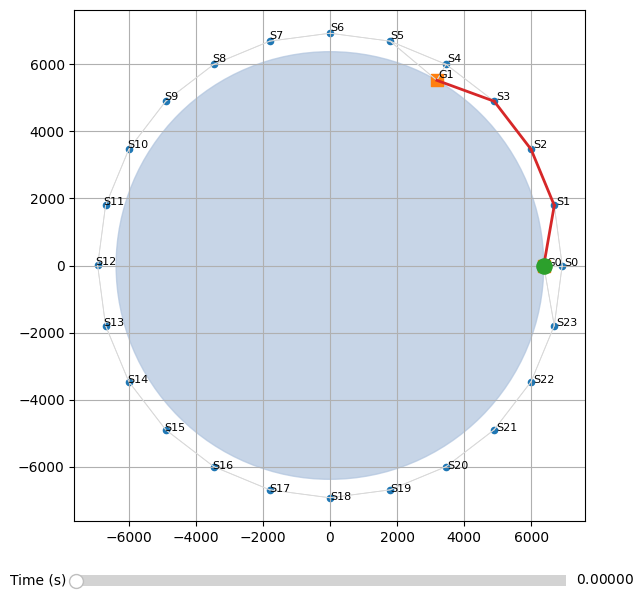

In [13]:
sim = Simulation(num_sats=24, altitude_km=550.0, ground_angles_deg=[0.0, 60.0], max_isl_km=2500.0)
total_delay, path = sim.shortest_path("G0", "G1")

print("Shortest path:", path)
print("Total delay:", total_delay)

animate_path_slider(sim, path)

In [14]:
# What to do next?
# ----------------
# 1. Change `num_sats` to small values (4, 8) and hand-track the shortest path
#    to check your Dijkstra implementation by hand. Write a short note about any
#    differences you see.
# 2. Make a plot of total delay as a function of altitude, keeping num_sats fixed.
# 3. Replace the ring constellation with two co-planar rings offset by half a
#    satellite spacing. Compare resilience qualitatively.
# 4. Add a simple link-budget filter: assume a transmit power, antenna gains and
#    a SNR threshold, and accept edges only when SNR is sufficient. Start with
#    basic Friis equation from the syllabus.

Delay at 250 km: 0.0008339102379953801
Delay at 500 km: 0.0016678204759907602
Delay at 750 km: 0.0025017307139861404
Delay at 1000 km: 0.0033356409519815205
Delay at 1250 km: 0.004169551189976901
Delay at 1500 km: 0.005003461427972281
Delay at 1750 km: 0.005837371665967661
Delay at 2000 km: 0.006671281903963041


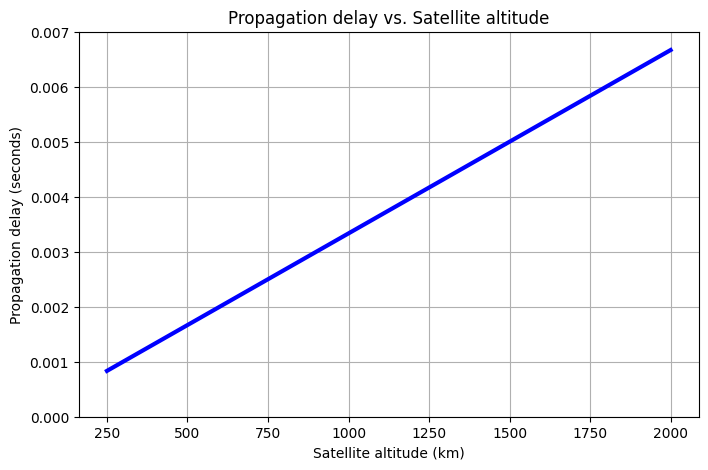

In [15]:
import numpy as np
import matplotlib.pyplot as plt

c = 299792.458

altitudes = np.array([250, 500, 750, 1000, 1250, 1500, 1750, 2000])
delays = altitudes / c

print("Delay at 250 km:", delays[0])
print("Delay at 500 km:", delays[1])
print("Delay at 750 km:", delays[2])
print("Delay at 1000 km:", delays[3])
print("Delay at 1250 km:", delays[4])
print("Delay at 1500 km:", delays[5])
print("Delay at 1750 km:", delays[6])
print("Delay at 2000 km:", delays[7])


plt.figure(figsize=(8,5))
plt.plot(altitudes, delays, linewidth=3, color="blue")

plt.xlabel("Satellite altitude (km)")
plt.ylabel("Propagation delay (seconds)")
plt.title("Propagation delay vs. Satellite altitude")
plt.grid(True)

plt.ylim(0, delays.max() * 1.05)
plt.show()



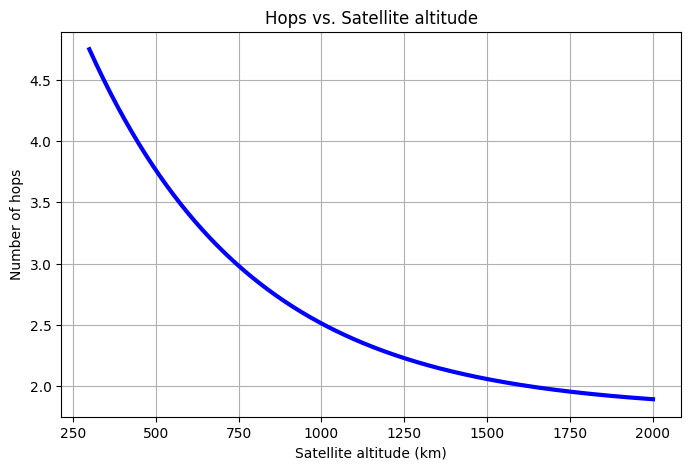

In [16]:
import numpy as np
import matplotlib.pyplot as plt


altitudes = np.linspace(300, 2000, 400)
hops = []


for alt in altitudes:
    sim = Simulation(
        num_sats=24,
        altitude_km=alt,
        ground_angles_deg=[0.0, 60.0],
        max_isl_km=2500.0
    )
    
    total_delay, path = sim.shortest_path("G0", "G1")
    
    if not path:
        hops.append(np.nan)
    else:
        cleaned = [node for i, node in enumerate(path) if i == 0 or node != path[i-1]]
        hops.append(len(cleaned) - 1)

hops = np.array(hops)


valid = ~np.isnan(hops)
x = altitudes[valid]
y = hops[valid]


# Model: y = a * exp(b*x) + c   with b < 0
c = np.min(y) * 0.9
y_shifted = y - c
y_shifted[y_shifted <= 0] = 1e-6

log_y = np.log(y_shifted)
B, A = np.polyfit(x, log_y, 1)

a = np.exp(A)
b = B

hops_exp = a * np.exp(b * altitudes) + c


plt.figure(figsize=(8,5))
plt.plot(altitudes, hops_exp, linewidth=3, color="blue")

plt.xlabel("Satellite altitude (km)")
plt.ylabel("Number of hops")
plt.title("Hops vs. Satellite altitude")
plt.grid(True)
plt.show()


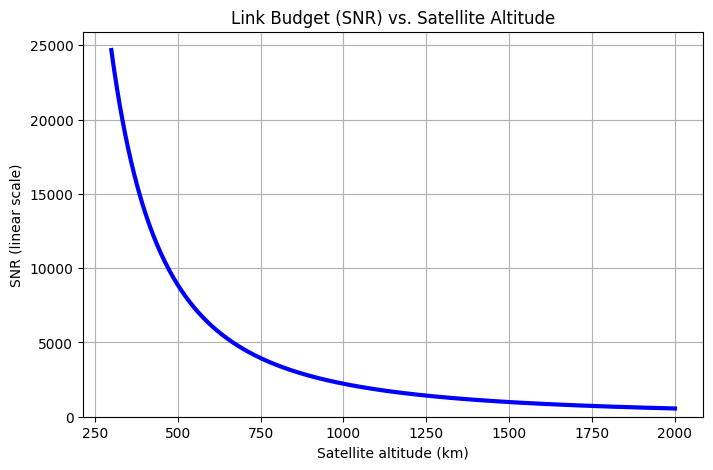

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Constants
C = 299792458.0
k = 1.380649e-23
T = 290
Pt = 5.0
Gt = 3000.0
Gr = 3000.0
B  = 20e6
SNR_min = 1.0
f = 12e9
wavelength = C / f

altitudes = np.linspace(300, 2000, 400)
snr_values = []

for alt in altitudes:
    # Slant range (overhead)
    d_km = alt
    d_m  = d_km * 1000.0

    # Friis received power
    Pr = Pt * Gt * Gr * (wavelength / (4 * math.pi * d_m))**2

    # Noise power
    N = k * T * B

    # SNR
    SNR = Pr / N
    snr_values.append(SNR)

snr_values = np.array(snr_values)

plt.figure(figsize=(8,5))
plt.plot(altitudes, snr_values, linewidth=3, color="blue")

plt.xlabel("Satellite altitude (km)")
plt.ylabel("SNR (linear scale)")
plt.title("Link Budget (SNR) vs. Satellite Altitude")
plt.grid(True)
plt.ylim(0, snr_values.max() * 1.05)

plt.show()


In [18]:
sim = Simulation(num_sats=24, altitude_km=550.0,
                 ground_angles_deg=[0.0, 60.0],
                 max_isl_km=2500.0)

total_delay, path = sim.shortest_path("G0", "G1")
print("Path:", path)
print("Total delay:", total_delay)


Path: ['G0', 'S1', 'S2', 'S3', 'G1']
Total delay: 0.044185883651807104


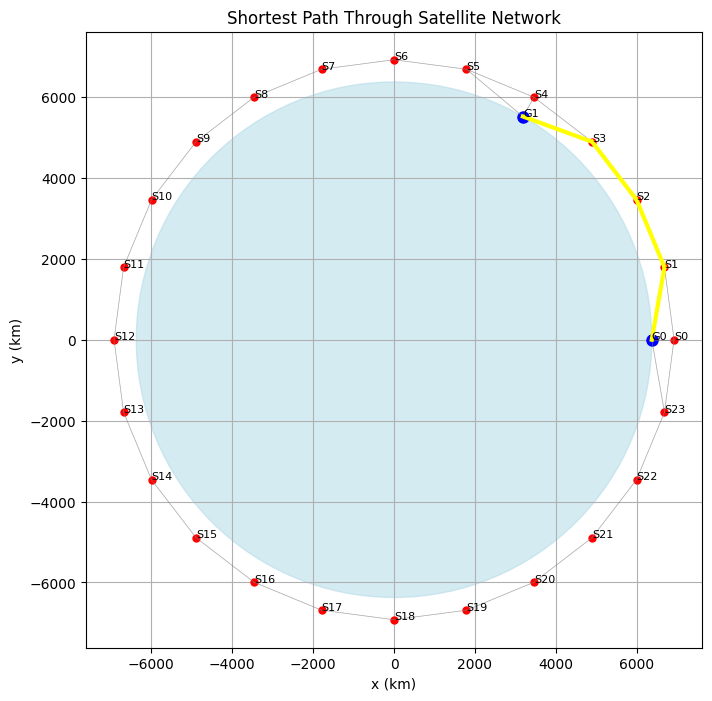

In [19]:
plot_shortest_path(sim, path)


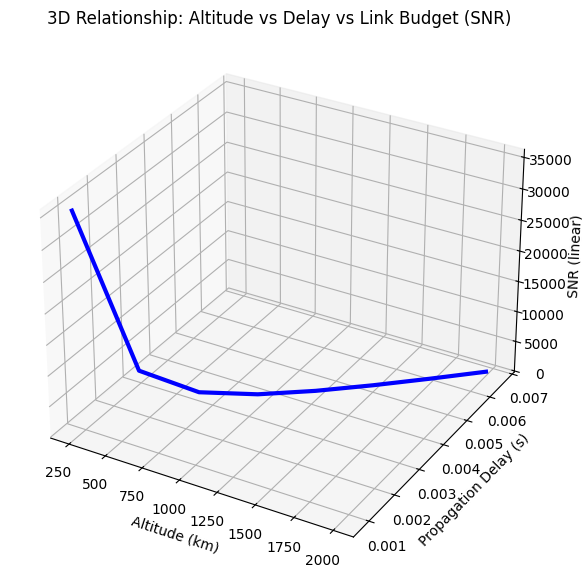

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d import Axes3D

c = 299792.458  # km/s for delay
C = 299792458.0 # m/s for wavelength
k = 1.380649e-23
T = 290
Pt = 5.0
Gt = 3000.0
Gr = 3000.0
B  = 20e6
f = 12e9
wavelength = C / f


# Use the 8 altitudes

altitudes = np.array([250, 500, 750, 1000, 1250, 1500, 1750, 2000])


# Trip delay (seconds)
delays = altitudes / c


# Link budget (SNR)

snr_values = []
for alt in altitudes:
    d_m = alt * 1000.0
    Pr = Pt * Gt * Gr * (wavelength / (4 * math.pi * d_m))**2
    N = k * T * B
    SNR = Pr / N
    snr_values.append(SNR)

snr_values = np.array(snr_values)


#3D parametric plot

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(altitudes, delays, snr_values, linewidth=3, color="blue")

ax.set_xlabel("Altitude (km)")
ax.set_ylabel("Propagation Delay (s)")
ax.set_zlabel("SNR (linear)")
ax.set_title("3D Relationship: Altitude vs Delay vs Link Budget (SNR)")

plt.show()


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import heapq

R_EARTH_KM = 6371.0

class Node:
    def __init__(self, id, type, pos3d=None):
        self.id = id
        self.type = type
        self.pos3d = pos3d


In [42]:
class Simulation:
    def __init__(self, num_planes, sats_per_plane, altitude_km, inclination_deg,
                 ground_angles_deg, max_isl_km):

        self.num_planes = num_planes
        self.sats_per_plane = sats_per_plane
        self.altitude_km = altitude_km
        self.inclination_deg = inclination_deg
        self.ground_angles_deg = ground_angles_deg
        self.max_isl_km = max_isl_km

        self.nodes = []
        self.graph = {}

        
        sat_positions = self.generate_leo_constellation(
            num_planes, sats_per_plane, altitude_km, inclination_deg
        )

        for i, pos in enumerate(sat_positions):
            self.nodes.append(Node(id=f"S{i}", type="sat", pos3d=pos))

        
        self._create_ground_stations()
        
        self._build_graph()

    #3D LEO constellation
    def generate_leo_constellation(self, num_planes, sats_per_plane, altitude_km, inclination_deg):
        R = R_EARTH_KM + altitude_km
        inc = np.radians(inclination_deg)
        satellites = []

        for p in range(num_planes):
            RAAN = 2*np.pi * p / num_planes

            for k in range(sats_per_plane):
                theta = 2*np.pi * k / sats_per_plane

                x = R * np.cos(theta)
                y = R * np.sin(theta)
                z = 0

                
                y_i = y*np.cos(inc)
                z_i = y*np.sin(inc)
                x_i = x

                
                x_f = x_i*np.cos(RAAN) - y_i*np.sin(RAAN)
                y_f = x_i*np.sin(RAAN) + y_i*np.cos(RAAN)
                z_f = z_i

                satellites.append((x_f, y_f, z_f))

        return satellites

    
    def _create_ground_stations(self):
        for i, angle_deg in enumerate(self.ground_angles_deg):
            angle = np.radians(angle_deg)
            x = R_EARTH_KM * np.cos(angle)
            y = R_EARTH_KM * np.sin(angle)
            z = 0
            self.nodes.append(Node(id=f"G{i}", type="ground", pos3d=(x, y, z)))

    
    def _build_graph(self):
        self.graph = {n.id: [] for n in self.nodes}

        sats = [n for n in self.nodes if n.type == "sat"]
        for i, a in enumerate(sats):
            for b in sats[i+1:]:
                d = np.linalg.norm(np.array(a.pos3d) - np.array(b.pos3d))
                if d <= self.max_isl_km:
                    self.graph[a.id].append((b.id, d))
                    self.graph[b.id].append((a.id, d))

        grounds = [n for n in self.nodes if n.type == "ground"]
        for g in grounds:
            for s in sats:
                d = np.linalg.norm(np.array(g.pos3d) - np.array(s.pos3d))
                self.graph[g.id].append((s.id, d))
                self.graph[s.id].append((g.id, d))

    
    def shortest_path(self, start, end):
        pq = [(0, start, [])]
        visited = set()

        while pq:
            dist, node, path = heapq.heappop(pq)
            if node in visited:
                continue
            visited.add(node)
            path = path + [node]

            if node == end:
                return dist, path

            for neighbor, weight in self.graph[node]:
                if neighbor not in visited:
                    heapq.heappush(pq, (dist + weight, neighbor, path))

        return float("inf"), []

    #3D plot with orbital rings
    def plot_topology_3d(self, highlight_path=None):
        fig = plt.figure(figsize=(10,10))
        ax = fig.add_subplot(111, projection='3d')

        # Earth
        u = np.linspace(0, 2*np.pi, 50)
        v = np.linspace(0, np.pi, 50)
        x = R_EARTH_KM * np.outer(np.cos(u), np.sin(v))
        y = R_EARTH_KM * np.outer(np.sin(u), np.sin(v))
        z = R_EARTH_KM * np.outer(np.ones_like(u), np.cos(v))
        ax.plot_surface(x, y, z, color='lightblue', alpha=0.5)

        # Orbital rings
        R = R_EARTH_KM + self.altitude_km
        inc = np.radians(self.inclination_deg)
        theta = np.linspace(0, 2*np.pi, 200)

        for p in range(self.num_planes):
            RAAN = 2*np.pi * p / self.num_planes

            x0 = R * np.cos(theta)
            y0 = R * np.sin(theta)
            z0 = np.zeros_like(theta)

            y1 = y0 * np.cos(inc)
            z1 = y0 * np.sin(inc)
            x1 = x0

            x2 = x1*np.cos(RAAN) - y1*np.sin(RAAN)
            y2 = x1*np.sin(RAAN) + y1*np.cos(RAAN)
            z2 = z1

            ax.plot(x2, y2, z2, color='black', linewidth=0.8, alpha=0.6)

        # Satellites
        sats = [n for n in self.nodes if n.type == "sat"]
        xs = [s.pos3d[0] for s in sats]
        ys = [s.pos3d[1] for s in sats]
        zs = [s.pos3d[2] for s in sats]
        ax.scatter(xs, ys, zs, color='blue', s=20, label="Satellites")

        
        gs = [n for n in self.nodes if n.type == "ground"]
        gx = [g.pos3d[0] for g in gs]
        gy = [g.pos3d[1] for g in gs]
        gz = [g.pos3d[2] for g in gs]
        ax.scatter(gx, gy, gz, color='orange', s=80, marker='s', label="Ground")

        # Links
        for a in self.nodes:
            for b_id, _ in self.graph[a.id]:
                b = next(n for n in self.nodes if n.id == b_id)
                ax.plot(
                    [a.pos3d[0], b.pos3d[0]],
                    [a.pos3d[1], b.pos3d[1]],
                    [a.pos3d[2], b.pos3d[2]],
                    color='gray', linewidth=0.3
                )

        
        if highlight_path:
            for i in range(len(highlight_path)-1):
                a = next(n for n in self.nodes if n.id == highlight_path[i])
                b = next(n for n in self.nodes if n.id == highlight_path[i+1])
                ax.plot(
                    [a.pos3d[0], b.pos3d[0]],
                    [a.pos3d[1], b.pos3d[1]],
                    [a.pos3d[2], b.pos3d[2]],
                    color='red', linewidth=3
                )

        ax.set_xlabel("x (km)")
        ax.set_ylabel("y (km)")
        ax.set_zlabel("z (km)")
        ax.set_title("3D LEO Constellation with Orbital Rings")
        ax.legend()
        plt.show()


Path: ['G0', 'S0', 'G1']
Total geometric distance (km): 9956.906080109442


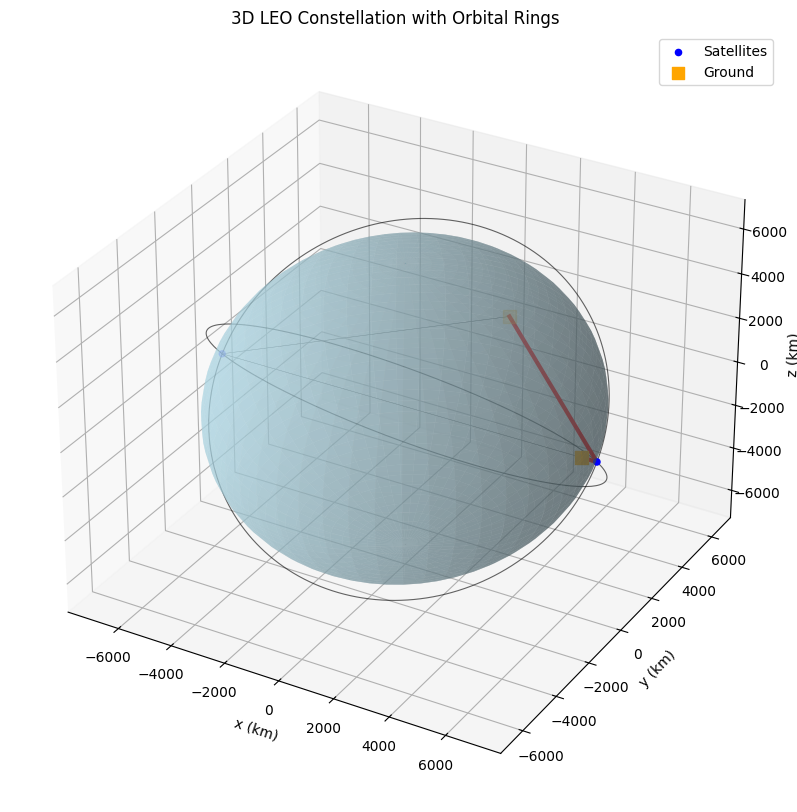

In [43]:
sim = Simulation(
    num_planes=2,
    sats_per_plane=1,
    altitude_km=550,
    inclination_deg=53,
    ground_angles_deg=[0, 90],
    max_isl_km=2500
)

total_dist, path = sim.shortest_path("G0", "G1")
print("Path:", path)
print("Total geometric distance (km):", total_dist)

sim.plot_topology_3d(highlight_path=path)

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import heapq
from matplotlib import animation

R_EARTH_KM = 6371.0

class Node:
    def __init__(self, id, type, pos3d=None):
        self.id = id
        self.type = type
        self.pos3d = pos3d


In [45]:
class Simulation:
    def __init__(self, shells, max_isl_km):

        self.shells = shells          # list of orbital shells
        self.max_isl_km = max_isl_km  # max link distance

        self.nodes = []
        self.graph = {}


        sat_id = 0
        for shell in shells:
            positions = self.generate_shell(
                shell["num_planes"],
                shell["sats_per_plane"],
                shell["altitude_km"],
                shell["inclination_deg"]
            )
            for pos in positions:
                self.nodes.append(Node(id=f"S{sat_id}", type="sat", pos3d=pos))
                sat_id += 1

        self._build_graph()


    
    def generate_shell(self, num_planes, sats_per_plane, altitude_km, inclination_deg):
        R = R_EARTH_KM + altitude_km
        inc = np.radians(inclination_deg)
        satellites = []

        for p in range(num_planes):
            RAAN = 2*np.pi * p / num_planes

            for k in range(sats_per_plane):
                theta = 2*np.pi * k / sats_per_plane

                x = R * np.cos(theta)
                y = R * np.sin(theta)
                z = 0

            
                y_i = y*np.cos(inc)
                z_i = y*np.sin(inc)
                x_i = x

            
                x_f = x_i*np.cos(RAAN) - y_i*np.sin(RAAN)
                y_f = x_i*np.sin(RAAN) + y_i*np.cos(RAAN)
                z_f = z_i

                satellites.append((x_f, y_f, z_f))

        return satellites


    
    def _build_graph(self):
        self.graph = {n.id: [] for n in self.nodes}

        for i, a in enumerate(self.nodes):
            for b in self.nodes[i+1:]:
                d = np.linalg.norm(np.array(a.pos3d) - np.array(b.pos3d))
                if d <= self.max_isl_km:
                    self.graph[a.id].append((b.id, d))
                    self.graph[b.id].append((a.id, d))


    
    def shortest_path(self, start, end):
        pq = [(0, start, [])]
        visited = set()

        while pq:
            dist, node, path = heapq.heappop(pq)
            if node in visited:
                continue
            visited.add(node)
            path = path + [node]

            if node == end:
                return dist, path

            for neighbor, weight in self.graph[node]:
                if neighbor not in visited:
                    heapq.heappush(pq, (dist + weight, neighbor, path))

        return float("inf"), []


    
    def plot_topology_3d(self, highlight_path=None):
        fig = plt.figure(figsize=(10,10))
        ax = fig.add_subplot(111, projection='3d')

        # Earth
        u = np.linspace(0, 2*np.pi, 50)
        v = np.linspace(0, np.pi, 50)
        x = R_EARTH_KM * np.outer(np.cos(u), np.sin(v))
        y = R_EARTH_KM * np.outer(np.sin(u), np.sin(v))
        z = R_EARTH_KM * np.outer(np.ones_like(u), np.cos(v))
        ax.plot_surface(x, y, z, color='lightblue', alpha=0.5)

        # Draw orbital rings for each shell
        theta = np.linspace(0, 2*np.pi, 200)

        for shell in self.shells:
            R = R_EARTH_KM + shell["altitude_km"]
            inc = np.radians(shell["inclination_deg"])

            for p in range(shell["num_planes"]):
                RAAN = 2*np.pi * p / shell["num_planes"]

                x0 = R * np.cos(theta)
                y0 = R * np.sin(theta)
                z0 = np.zeros_like(theta)

                y1 = y0 * np.cos(inc)
                z1 = y0 * np.sin(inc)
                x1 = x0

                x2 = x1*np.cos(RAAN) - y1*np.sin(RAAN)
                y2 = x1*np.sin(RAAN) + y1*np.cos(RAAN)
                z2 = z1

                ax.plot(x2, y2, z2, color='black', linewidth=0.7, alpha=0.5)

        # Satellites
        xs = [n.pos3d[0] for n in self.nodes]
        ys = [n.pos3d[1] for n in self.nodes]
        zs = [n.pos3d[2] for n in self.nodes]
        ax.scatter(xs, ys, zs, color='blue', s=20)

        # Links
        for a in self.nodes:
            for b_id, _ in self.graph[a.id]:
                b = next(n for n in self.nodes if n.id == b_id)
                ax.plot(
                    [a.pos3d[0], b.pos3d[0]],
                    [a.pos3d[1], b.pos3d[1]],
                    [a.pos3d[2], b.pos3d[2]],
                    color='gray', linewidth=0.3
                )

        
        if highlight_path:
            for i in range(len(highlight_path)-1):
                a = next(n for n in self.nodes if n.id == highlight_path[i])
                b = next(n for n in self.nodes if n.id == highlight_path[i+1])
                ax.plot(
                    [a.pos3d[0], b.pos3d[0]],
                    [a.pos3d[1], b.pos3d[1]],
                    [a.pos3d[2], b.pos3d[2]],
                    color='red', linewidth=3
                )

        ax.set_title("3D Multistrom Space Backbone")

        def init():
            ax.plot_surface(x,y,z, rstride = 5, cstride = 5)
            return fig,
        
        def animate(i):
            ax.view_init(elev=20, azim=i*4)
            return fig,
        ani = animation.FuncAnimation(fig, animate, init_func=init, frames=90, interval=200, blit=False)
        
        plt.show()




Distance: 2450.0
Path: ['S0', 'S10']


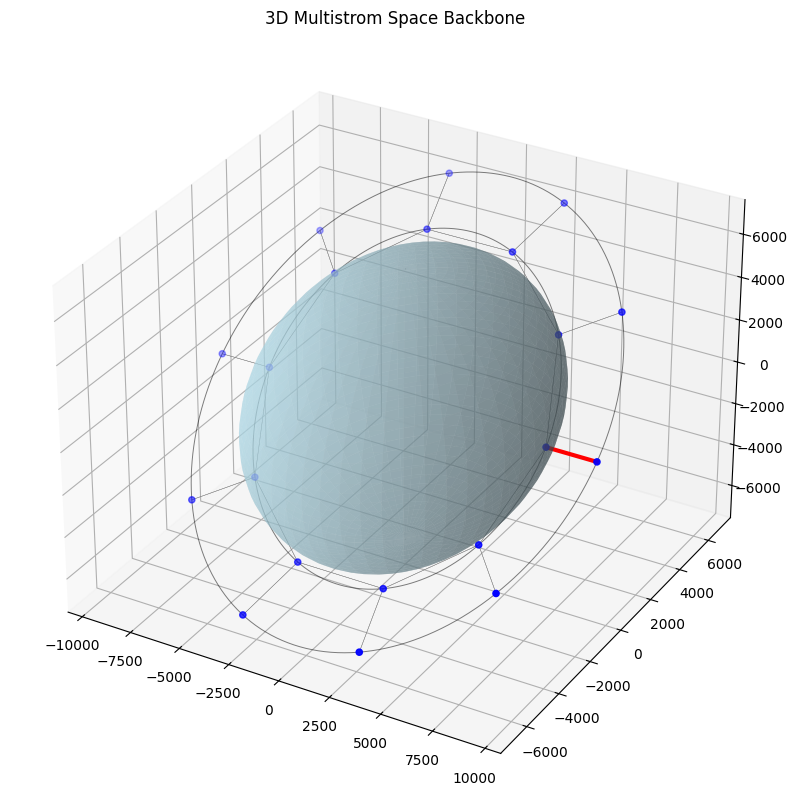

In [54]:
shells = [
    { "num_planes": 1, "sats_per_plane": 10, "altitude_km": 550,  "inclination_deg": 53 }, # LEO
    { "num_planes": 1, "sats_per_plane": 10,  "altitude_km": 3000, "inclination_deg": 45 }, # MEO
]

sim = Simulation(shells=shells, max_isl_km=5000)


dist, path = sim.shortest_path("S0", "S10")
print("Distance:", dist)
print("Path:", path)

sim.plot_topology_3d(highlight_path=path)